# Prototyping Notebook for Experimentation

In [ ]:
import os
import sys
import cv2
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from torch.autograd import Variable

#### Test the difference between the ground truth data of RGB images and the IR images as they differ

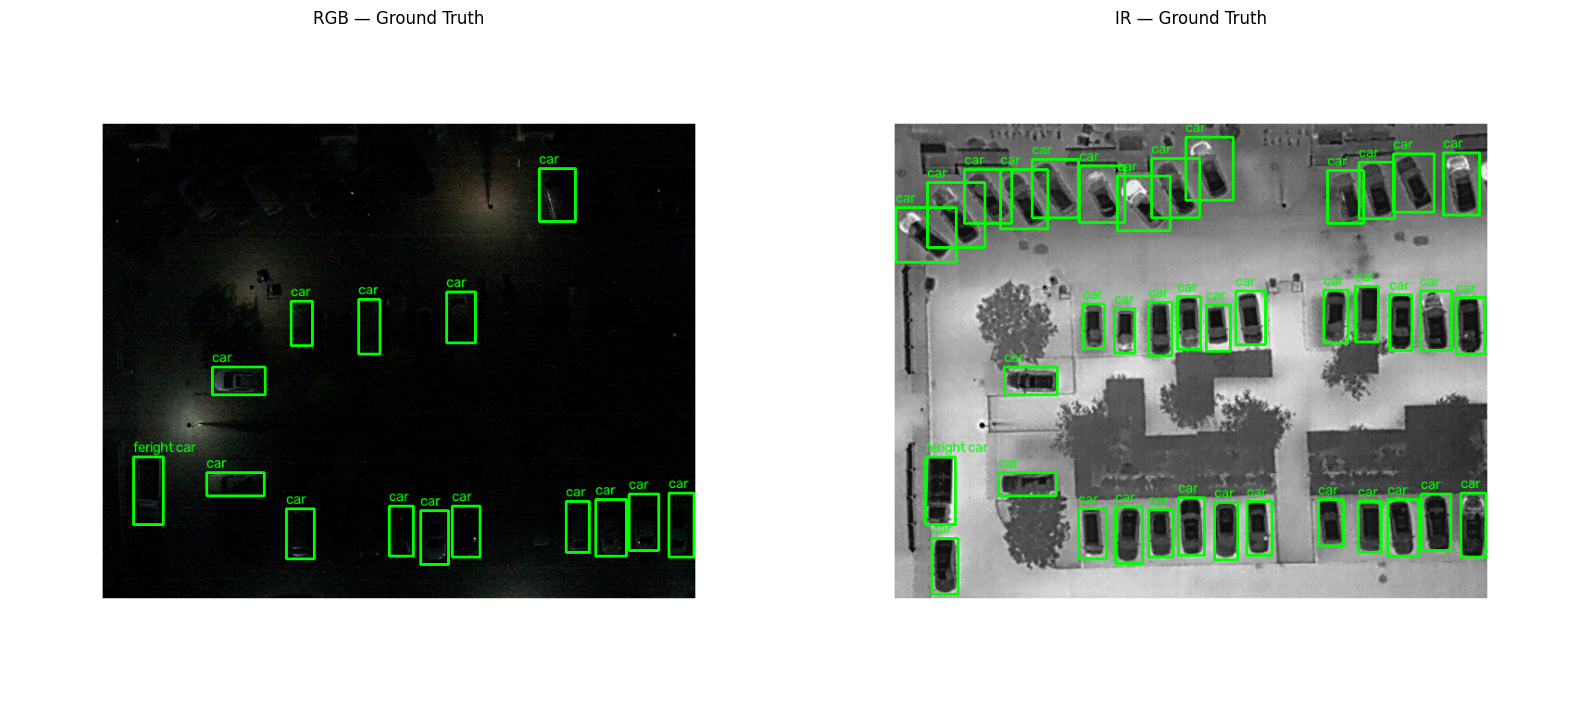

In [2]:
def load_gt_boxes(xml_path):
    """
    Load ground-truth polygons from the XML and convert them
    to axis-aligned bounding boxes.

    Returns:
        List of dictionaries containing:
        x1, y1, x2, y2, class_name
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        polygon = obj.find("polygon")

        # Get the four polygon points
        points = []
        for i in range(1, 5):
            x = int(float(polygon.find(f"x{i}").text))
            y = int(float(polygon.find(f"y{i}").text))
            points.append((x, y))

        # Convert polygon to enclosing bounding box
        xs = [point[0] for point in points]
        ys = [point[1] for point in points]

        boxes.append({
            "x1": min(xs),
            "y1": min(ys),
            "x2": max(xs),
            "y2": max(ys),
            "class_name": class_name
        })

    return boxes


def plot_gt(image_path, xml_path):
    """
    Load an image and XML ground truth, draw bounding boxes
    and labels, and return the image.
    """
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Convert BGR -> RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes = load_gt_boxes(xml_path)

    for box in boxes:
        x1 = box["x1"]
        y1 = box["y1"]
        x2 = box["x2"]
        y2 = box["y2"]
        class_name = box["class_name"]

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            class_name,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    return image


# ---------------------------------------------------------
# Set your RGB and IR paths here
# ---------------------------------------------------------

rgb_image_path = "./test_images/00001_rgb.jpg"
rgb_xml_path   = "./test_images/00001_rgb.xml"

ir_image_path = "./test_images/00001_ir.jpg"
ir_xml_path   = "./test_images/00001_ir.xml"


# ---------------------------------------------------------
# Load images with ground-truth detections
# ---------------------------------------------------------

rgb_image = plot_gt(
    rgb_image_path,
    rgb_xml_path
)

ir_image = plot_gt(
    ir_image_path,
    ir_xml_path
)


# ---------------------------------------------------------
# Display side-by-side
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(rgb_image)
axes[0].set_title("RGB — Ground Truth")
axes[0].axis("off")

axes[1].imshow(ir_image)
axes[1].set_title("IR — Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Now, highlight the differences between the two images in red.

In [3]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes.
    Boxes are dictionaries with x1, y1, x2, y2.
    """
    x1 = max(box1["x1"], box2["x1"])
    y1 = max(box1["y1"], box2["y1"])
    x2 = min(box1["x2"], box2["x2"])
    y2 = min(box1["y2"], box2["y2"])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)
    intersection = intersection_width * intersection_height

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - intersection

    if union == 0:
        return 0

    return intersection / union


def draw_box(image, box, color, thickness=2):
    """Draw a bounding box and label."""
    x1 = box["x1"]
    y1 = box["y1"]
    x2 = box["x2"]
    y2 = box["y2"]
    label = box["class_name"]

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        color,
        thickness
    )

    cv2.putText(
        image,
        label,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        1
    )


def compare_rgb_ir_gt(rgb_image_path, rgb_xml_path, ir_image_path, ir_xml_path,
                      iou_threshold=0.5):

    # Load images
    rgb_image = cv2.imread(rgb_image_path)
    ir_image = cv2.imread(ir_image_path)

    if rgb_image is None:
        raise FileNotFoundError(f"Could not load RGB image: {rgb_image_path}")

    if ir_image is None:
        raise FileNotFoundError(f"Could not load IR image: {ir_image_path}")

    # Convert BGR -> RGB for matplotlib
    rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB)
    ir_image = cv2.cvtColor(ir_image, cv2.COLOR_BGR2RGB)

    # Load GT
    rgb_boxes = load_gt_boxes(rgb_xml_path)
    ir_boxes = load_gt_boxes(ir_xml_path)

    # Track which IR boxes have already been matched
    matched_ir = set()

    rgb_only = []
    ir_only = []
    matched_pairs = []

    # ---------------------------------------------------------
    # Match RGB boxes to IR boxes using IoU
    # ---------------------------------------------------------

    for rgb_idx, rgb_box in enumerate(rgb_boxes):

        best_iou = 0
        best_ir_idx = None

        for ir_idx, ir_box in enumerate(ir_boxes):

            if ir_idx in matched_ir:
                continue

            # Optional: require same class
            if rgb_box["class_name"] != ir_box["class_name"]:
                continue

            iou = calculate_iou(rgb_box, ir_box)

            if iou > best_iou:
                best_iou = iou
                best_ir_idx = ir_idx

        if best_ir_idx is not None and best_iou >= iou_threshold:

            matched_ir.add(best_ir_idx)

            matched_pairs.append({
                "rgb_idx": rgb_idx,
                "ir_idx": best_ir_idx,
                "iou": best_iou
            })

        else:
            rgb_only.append(rgb_idx)

    # Any IR boxes that were never matched are IR-only
    ir_only = [
        i for i in range(len(ir_boxes))
        if i not in matched_ir
    ]

    # ---------------------------------------------------------
    # Draw RGB boxes
    # ---------------------------------------------------------

    for idx, box in enumerate(rgb_boxes):

        if idx in rgb_only:
            # RGB-only → RED
            draw_box(rgb_image, box, (255, 0, 0), 3)

        else:
            # Matched → GREEN
            draw_box(rgb_image, box, (0, 255, 0), 2)

    # ---------------------------------------------------------
    # Draw IR boxes
    # ---------------------------------------------------------

    for idx, box in enumerate(ir_boxes):

        if idx in ir_only:
            # IR-only → RED
            draw_box(ir_image, box, (255, 0, 0), 3)

        else:
            # Matched → GREEN
            draw_box(ir_image, box, (0, 255, 0), 2)

    # ---------------------------------------------------------
    # Print results
    # ---------------------------------------------------------

    print("=" * 60)
    print("RGB ↔ IR GROUND TRUTH COMPARISON")
    print("=" * 60)

    print(f"\nRGB GT objects: {len(rgb_boxes)}")
    print(f"IR GT objects:  {len(ir_boxes)}")

    print(f"\nMatched objects: {len(matched_pairs)}")
    print(f"RGB-only objects: {len(rgb_only)}")
    print(f"IR-only objects:  {len(ir_only)}")

    print("\n" + "-" * 60)
    print("MATCHED OBJECTS")
    print("-" * 60)

    for pair in matched_pairs:
        rgb_idx = pair["rgb_idx"]
        ir_idx = pair["ir_idx"]
        iou = pair["iou"]

        print(
            f"RGB [{rgb_idx}] ↔ IR [{ir_idx}] | "
            f"Label: {rgb_boxes[rgb_idx]['class_name']} | "
            f"IoU: {iou:.3f}"
        )

    print("\n" + "-" * 60)
    print("RGB-ONLY OBJECTS")
    print("-" * 60)

    for idx in rgb_only:
        box = rgb_boxes[idx]
        print(
            f"RGB [{idx}] | "
            f"Label: {box['class_name']} | "
            f"Box: ({box['x1']}, {box['y1']}) → "
            f"({box['x2']}, {box['y2']})"
        )

    print("\n" + "-" * 60)
    print("IR-ONLY OBJECTS")
    print("-" * 60)

    for idx in ir_only:
        box = ir_boxes[idx]
        print(
            f"IR [{idx}] | "
            f"Label: {box['class_name']} | "
            f"Box: ({box['x1']}, {box['y1']}) → "
            f"({box['x2']}, {box['y2']})"
        )

    # ---------------------------------------------------------
    # Display images
    # ---------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(rgb_image)
    axes[0].set_title(
        f"RGB Ground Truth\n"
        f"Green: Matched | Red: RGB-only"
    )
    axes[0].axis("off")

    axes[1].imshow(ir_image)
    axes[1].set_title(
        f"IR Ground Truth\n"
        f"Green: Matched | Red: IR-only"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

RGB ↔ IR GROUND TRUTH COMPARISON

RGB GT objects: 15
IR GT objects:  39

Matched objects: 15
RGB-only objects: 0
IR-only objects:  24

------------------------------------------------------------
MATCHED OBJECTS
------------------------------------------------------------
RGB [0] ↔ IR [1] | Label: feright car | IoU: 1.000
RGB [1] ↔ IR [2] | Label: car | IoU: 1.000
RGB [2] ↔ IR [3] | Label: car | IoU: 1.000
RGB [3] ↔ IR [7] | Label: car | IoU: 0.674
RGB [4] ↔ IR [10] | Label: car | IoU: 1.000
RGB [5] ↔ IR [11] | Label: car | IoU: 1.000
RGB [6] ↔ IR [12] | Label: car | IoU: 1.000
RGB [7] ↔ IR [13] | Label: car | IoU: 1.000
RGB [8] ↔ IR [14] | Label: car | IoU: 1.000
RGB [9] ↔ IR [15] | Label: car | IoU: 0.882
RGB [10] ↔ IR [35] | Label: car | IoU: 0.764
RGB [11] ↔ IR [17] | Label: car | IoU: 0.848
RGB [12] ↔ IR [20] | Label: car | IoU: 0.811
RGB [13] ↔ IR [6] | Label: car | IoU: 0.730
RGB [14] ↔ IR [8] | Label: car | IoU: 0.802

-----------------------------------------------------------

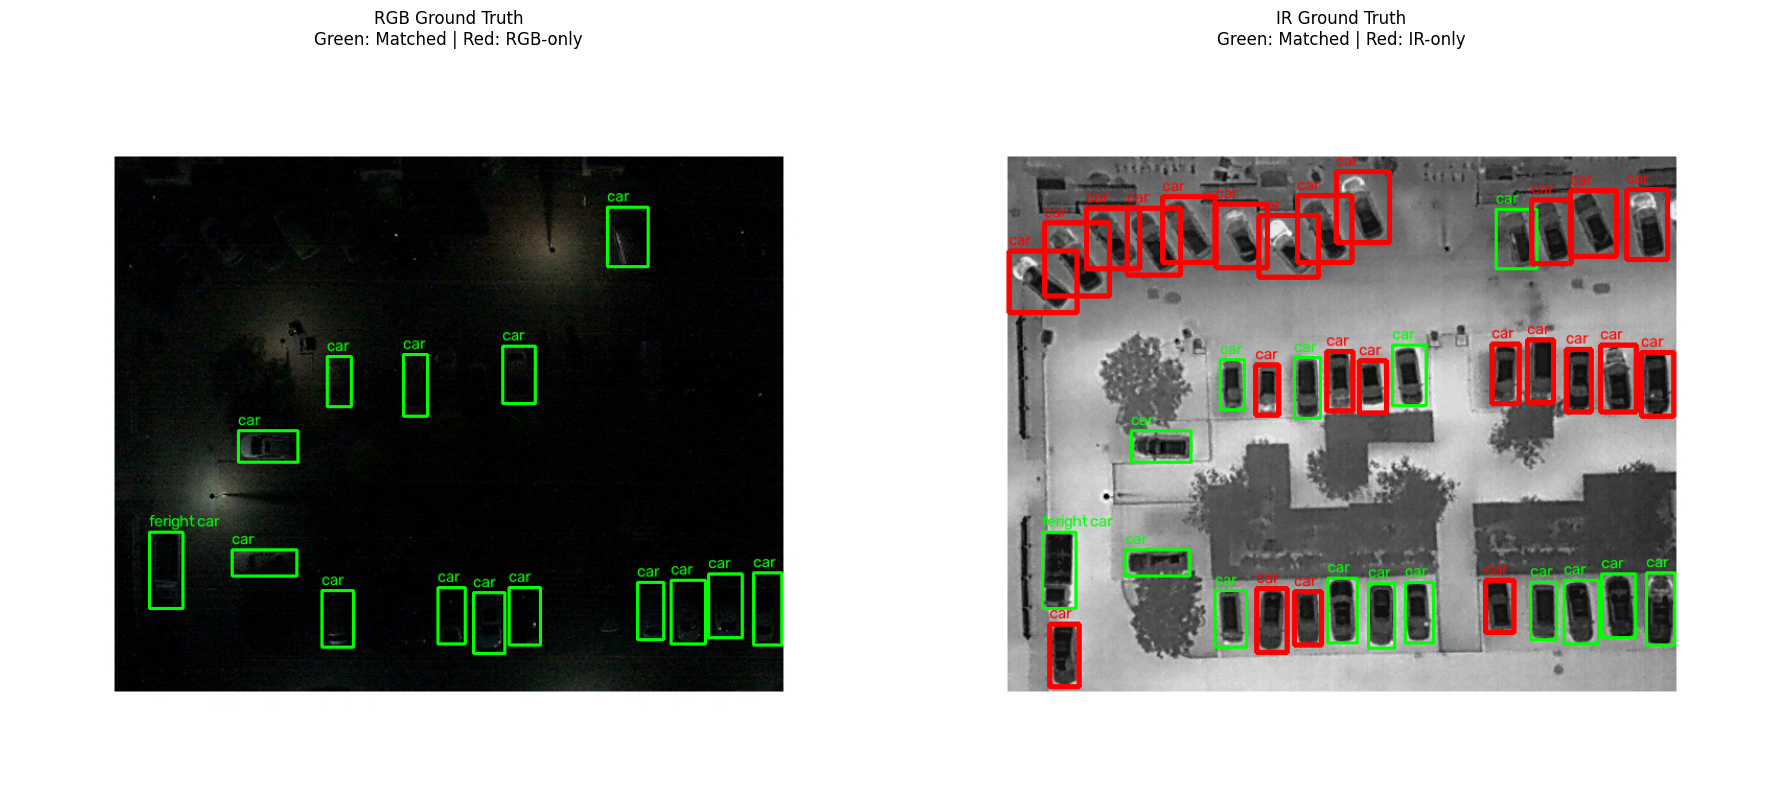

In [4]:
compare_rgb_ir_gt(
    rgb_image_path,
    rgb_xml_path,
    ir_image_path,
    ir_xml_path,
    iou_threshold=0.5
)

#### Test what resize to 256 x 256 looks like

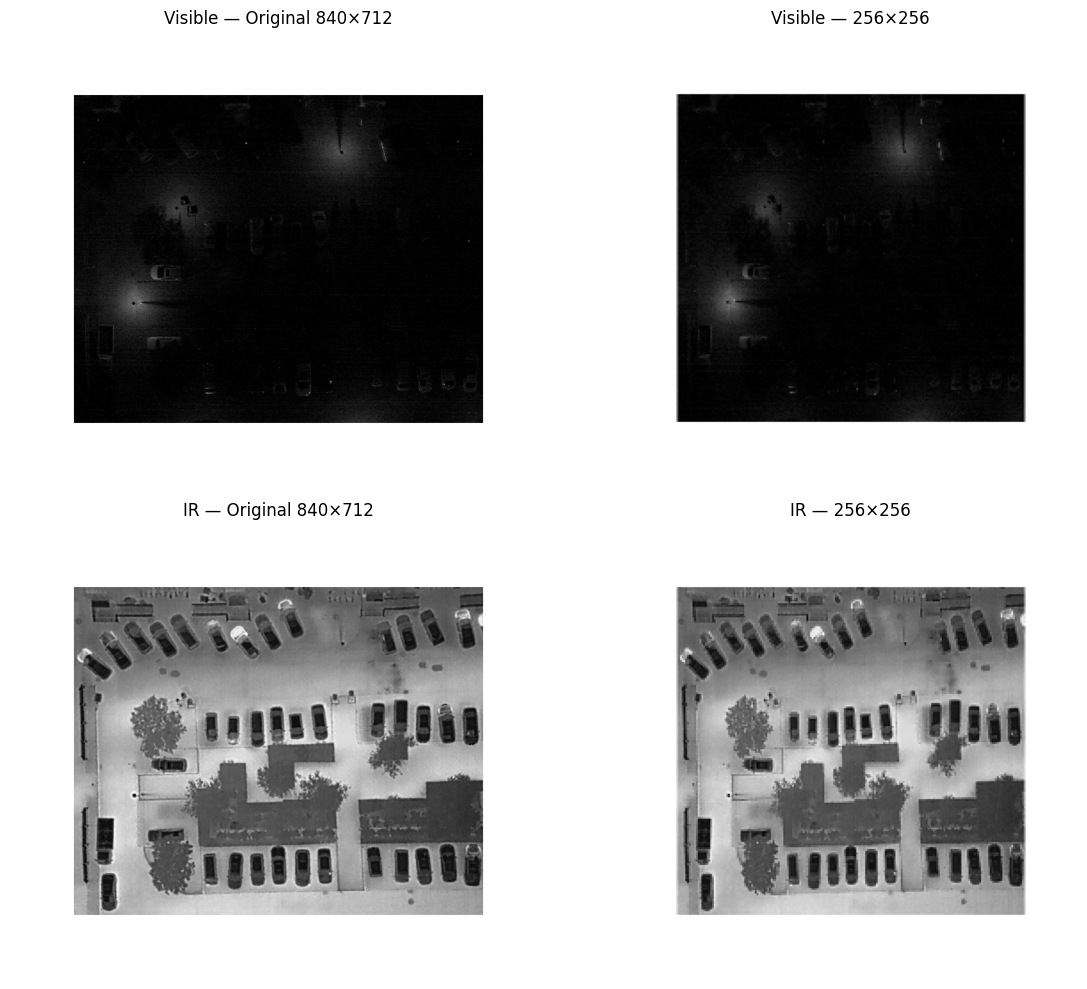

In [8]:
rgb = cv2.imread(str(rgb_image_path), cv2.IMREAD_GRAYSCALE)
ir = cv2.imread(str(ir_image_path), cv2.IMREAD_GRAYSCALE)

rgb_256 = cv2.resize(rgb, (256, 256))
ir_256 = cv2.resize(ir, (256, 256))

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(rgb, cmap="gray")
plt.title(f"Visible — Original {rgb.shape[1]}×{rgb.shape[0]}")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(rgb_256, cmap="gray")
plt.title("Visible — 256×256")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(ir, cmap="gray")
plt.title(f"IR — Original {ir.shape[1]}×{ir.shape[0]}")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(ir_256, cmap="gray")
plt.title("IR — 256×256")
plt.axis("off")

plt.tight_layout()
plt.show()

This looks reasonable and the paper uses 256x256 size, and it will also make computations faster. From the looks of it, we lose a lot of details so lets investigate if this is fine or if we should up the resolution.

#### Investigate the CrossFuse pipeline to see how it works and how to use it for a single image pair.

In [12]:
# Took contents of "test_color_image.py" and changed it up a bit

# Get PACE/
REPO_ROOT = Path.cwd().parent

# PACE/baseline/CrossFuse/
CROSSFUSE_ROOT = REPO_ROOT / "baseline" / "CrossFuse"

# Add CrossFuse to Python's import path
sys.path.insert(0, str(CROSSFUSE_ROOT))

# CrossFuse imports
from network.net_autoencoder import Auto_Encoder_single
from network.net_conv_trans import Trans_FuseNet
from tools import utils


# ============================================================
# Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = [
    "car",
    "truck",
    "bus",
    "van",
    "freight_car"
]

# ---- Single input pair ----
ir_path = str(REPO_ROOT / "prototyping" / "test_images" / "00001_ir.jpg")
vi_path = str(REPO_ROOT / "prototyping" / "test_images" / "00001_rgb.jpg")

# ---- Model paths ----
model_path_auto_ir = str(CROSSFUSE_ROOT / "models" / "autoencoder" / "auto_encoder_epoch_4_ir.model")
model_path_auto_vi = str(CROSSFUSE_ROOT / "models" / "autoencoder" / "auto_encoder_epoch_4_vi.model")
model_path_trans = str(CROSSFUSE_ROOT / "models" / "transfuse" / "fusetrans_epoch_32_bs_8_num_20k_lr_0.1_s1_c1.model")

# CrossFuse setting
shift_flag = True

# Detection threshold
detection_threshold = 0.5


# ============================================================
# Model configuration
# ============================================================

custom_config_auto = {
    "in_channels": 1,
    "out_channels": 1,
    "en_out_channels1": 32,
    "en_out_channels": 64,
    "num_layers": 3,
    "dense_out": 128,
    "part_out": 128,
    "train_flag": False,
}

custom_config_trans = {
    "en_out_channels1": 32,
    "out_channels": 1,
    "part_out": 128,
    "train_flag": False,

    "img_size": 32,
    "patch_size": 2,
    "depth_self": 1,
    "depth_cross": 1,
    "n_heads": 16,
    "qkv_bias": True,
    "mlp_ratio": 4,
    "p": 0.,
    "attn_p": 0.,
}


# ============================================================
# Load models
# ============================================================

model_auto_ir = Auto_Encoder_single(**custom_config_auto)
model_auto_ir.load_state_dict(
    torch.load(model_path_auto_ir, map_location=DEVICE)
)
model_auto_ir.to(DEVICE)
model_auto_ir.eval()

model_auto_vi = Auto_Encoder_single(**custom_config_auto)
model_auto_vi.load_state_dict(
    torch.load(model_path_auto_vi, map_location=DEVICE)
)
model_auto_vi.to(DEVICE)
model_auto_vi.eval()

model_trans = Trans_FuseNet(**custom_config_trans)
model_trans.load_state_dict(
    torch.load(model_path_trans, map_location=DEVICE),
    strict=False
)
model_trans.to(DEVICE)
model_trans.eval()

print("Models loaded successfully.")
print("Device:", DEVICE)


# ============================================================
# Load single IR + VI image
# ============================================================

ir_img = utils.get_train_images(
    ir_path,
    None,        # delete if want to resize to 256x256
    None,        # delete if want to resize to 256x256
    flag=False
)

vi_img, vi_cb, vi_cr = utils.get_test_images_color(
    vi_path,
    None,        # delete if want to resize to 256x256
    None,        # delete if want to resize to 256x256
    flag=True
)

ir_img = Variable(ir_img, requires_grad=False).to(DEVICE)
vi_img = Variable(vi_img, requires_grad=False).to(DEVICE)


# ============================================================
# Run through CrossFuse pipeline
# ============================================================

with torch.no_grad():

    # IR autoencoder
    ir_sh, ir_de = model_auto_ir(ir_img)

    # Visible autoencoder
    vi_sh, vi_de = model_auto_vi(vi_img)

    # Transformer fusion + detection head
    outputs = model_trans(
        ir_de,
        ir_sh,
        vi_de,
        vi_sh,
        shift_flag
    )


# ============================================================
# Inspect model outputs
# ============================================================

print("\n========== MODEL OUTPUT ==========")

print(
    "Fused feature shape:",
    outputs["fused_features"].shape
)

print(
    "Detection output shape:",
    outputs["detections"].shape
)


# ============================================================
# Decode detections
# ============================================================

def decode_detections(
    detections,
    image_width,
    image_height,
    threshold=0.5
):

    detections = detections[0]

    # Objectness
    objectness = torch.sigmoid(detections[0])

    # Bounding box coordinates
    x = torch.sigmoid(detections[1])
    y = torch.sigmoid(detections[2])
    w = torch.sigmoid(detections[3])
    h = torch.sigmoid(detections[4])

    # Class predictions
    class_scores = torch.softmax(
        detections[5:10],
        dim=0
    )

    feature_height = detections.shape[1]
    feature_width = detections.shape[2]

    boxes = []

    for row in range(feature_height):
        for col in range(feature_width):

            obj_confidence = objectness[row, col].item()

            if obj_confidence < threshold:
                continue

            # Most likely class
            class_score, class_id = torch.max(
                class_scores[:, row, col],
                dim=0
            )

            class_score = class_score.item()
            class_id = class_id.item()

            # Combined confidence
            confidence = obj_confidence * class_score

            if confidence < threshold:
                continue

            # Convert normalized coordinates to image coordinates
            center_x = (
                x[row, col].item() * image_width
            )

            center_y = (
                y[row, col].item() * image_height
            )

            box_width = (
                w[row, col].item() * image_width
            )

            box_height = (
                h[row, col].item() * image_height
            )

            x1 = int(center_x - box_width / 2)
            y1 = int(center_y - box_height / 2)

            x2 = int(center_x + box_width / 2)
            y2 = int(center_y + box_height / 2)

            # Clamp to image boundaries
            x1 = max(0, min(x1, image_width - 1))
            y1 = max(0, min(y1, image_height - 1))
            x2 = max(0, min(x2, image_width - 1))
            y2 = max(0, min(y2, image_height - 1))

            boxes.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "confidence": confidence,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id]
            })

    return boxes


# ============================================================
# Decode detections on original VI image
# ============================================================

vi_original = cv2.imread(vi_path)

if vi_original is None:
    raise FileNotFoundError(
        f"Could not load VI image: {vi_path}"
    )

image_height, image_width = vi_original.shape[:2]

boxes = decode_detections(
    outputs["detections"],
    image_width,
    image_height,
    threshold=detection_threshold
)

print("\nNumber of detections:", len(boxes))

for i, box in enumerate(boxes):

    print(
        f"Detection {i + 1}: "
        f"{box['class_name']} "
        f"confidence={box['confidence']:.3f} "
        f"box=({box['x1']}, {box['y1']}, "
        f"{box['x2']}, {box['y2']})"
    )

Models loaded successfully.
Device: cpu

========== MODEL OUTPUT ==========
Fused feature shape: torch.Size([1, 128, 89, 105])
Detection output shape: torch.Size([1, 10, 89, 105])

Number of detections: 0


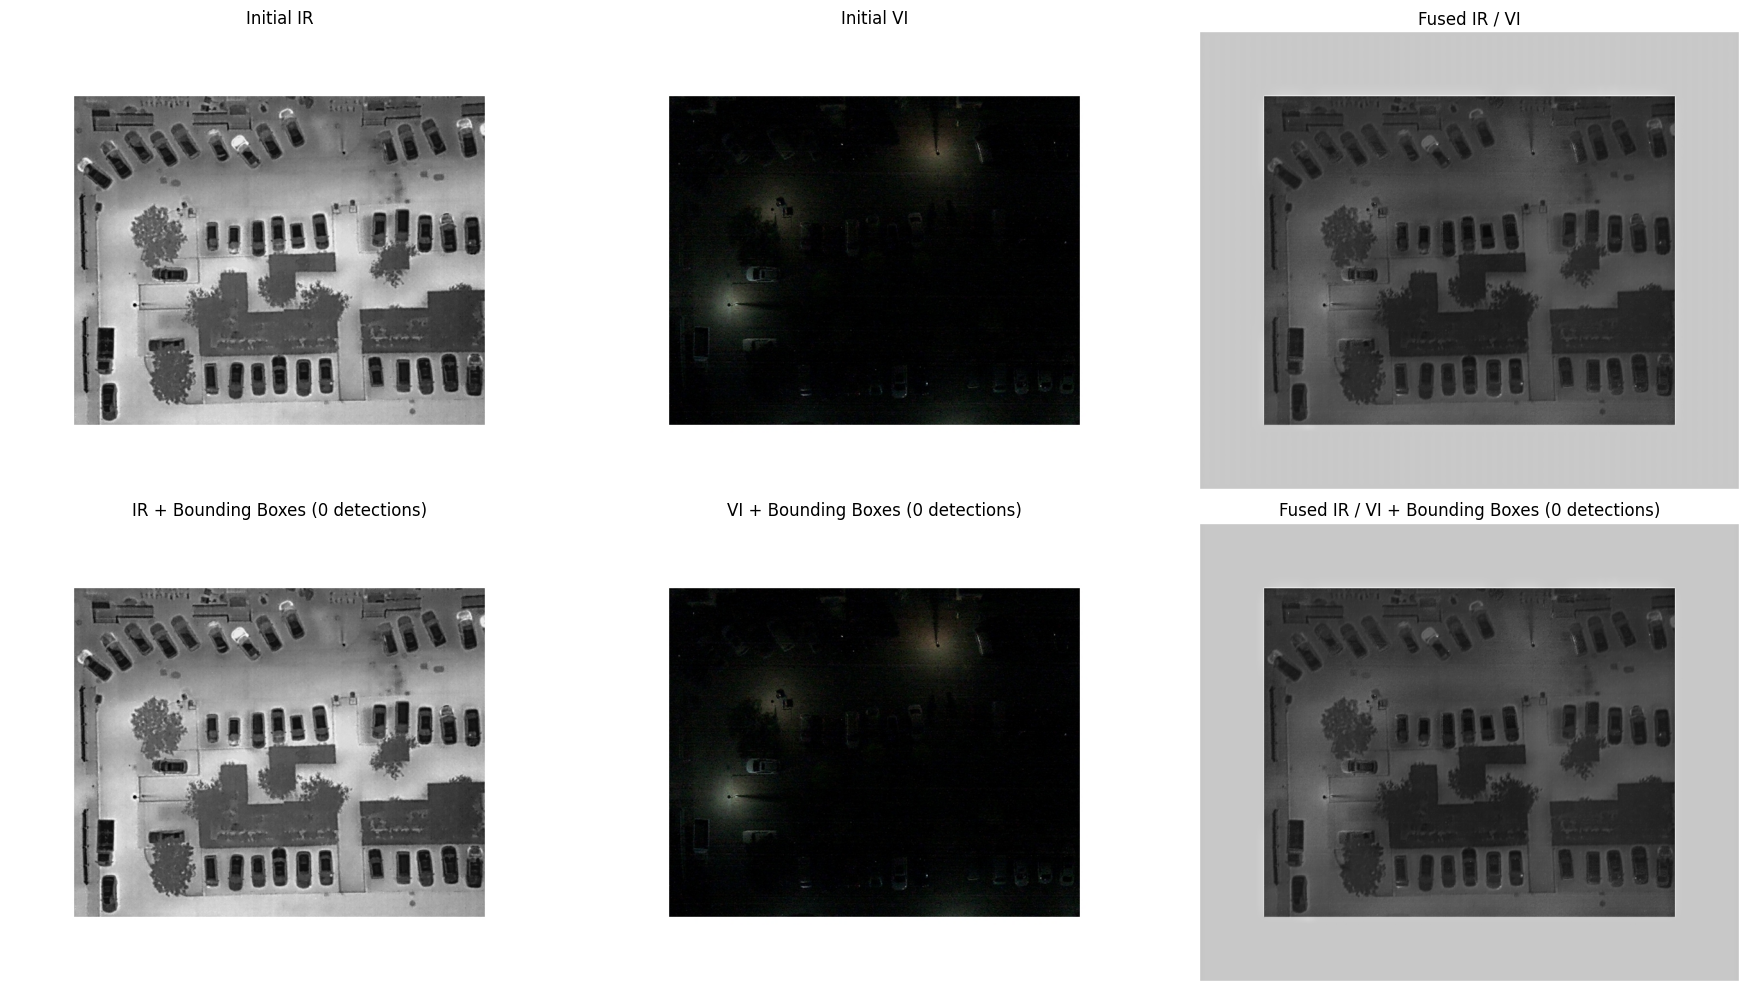

In [13]:
# ============================================================
# Display:
#   1. Initial IR
#   2. Initial VI
#   3. Fused IR/VI
#   4. IR + detections
#   5. VI + detections
#   6. Fused IR/VI + detections
# ============================================================

import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch


# ------------------------------------------------------------
# Helper: convert a CrossFuse tensor/image to displayable
# numpy image
# ------------------------------------------------------------

def tensor_to_image(tensor):
    """
    Convert a CrossFuse output tensor into a numpy image
    suitable for matplotlib.
    """

    if isinstance(tensor, torch.Tensor):
        tensor = tensor.detach().cpu()

        # Remove batch dimension
        if tensor.dim() == 4:
            tensor = tensor[0]

        # CHW -> HWC
        if tensor.dim() == 3:
            if tensor.shape[0] in [1, 3]:
                tensor = tensor.permute(1, 2, 0)

        tensor = tensor.numpy()

    tensor = np.asarray(tensor)

    # Remove single channel dimension
    if tensor.ndim == 3 and tensor.shape[2] == 1:
        tensor = tensor[:, :, 0]

    # Normalize for visualization
    tensor_min = tensor.min()
    tensor_max = tensor.max()

    if tensor_max > tensor_min:
        tensor = (tensor - tensor_min) / (tensor_max - tensor_min)

    return tensor


# ------------------------------------------------------------
# Load original images
# ------------------------------------------------------------

ir_original = cv2.imread(ir_path, cv2.IMREAD_GRAYSCALE)
vi_original = cv2.imread(vi_path, cv2.IMREAD_COLOR)

if ir_original is None:
    raise FileNotFoundError(f"Could not load IR image: {ir_path}")

if vi_original is None:
    raise FileNotFoundError(f"Could not load VI image: {vi_path}")


# ------------------------------------------------------------
# Get fused output
# ------------------------------------------------------------

fused = outputs["out"]

fused_image = tensor_to_image(fused)


# ------------------------------------------------------------
# Make copies for drawing detections
# ------------------------------------------------------------

ir_detection = cv2.cvtColor(
    ir_original,
    cv2.COLOR_GRAY2RGB
)

vi_detection = cv2.cvtColor(
    vi_original,
    cv2.COLOR_BGR2RGB
)

# Resize fused image to match original VI dimensions
fused_display = cv2.resize(
    fused_image,
    (vi_original.shape[1], vi_original.shape[0])
)

# Convert grayscale fused image to RGB for drawing
if fused_display.ndim == 2:
    fused_detection = np.stack(
        [fused_display] * 3,
        axis=-1
    )
else:
    fused_detection = fused_display.copy()


# ------------------------------------------------------------
# Draw detections on each image
# ------------------------------------------------------------

for box in boxes:

    x1 = box["x1"]
    y1 = box["y1"]
    x2 = box["x2"]
    y2 = box["y2"]

    confidence = box["confidence"]
    class_name = box["class_name"]

    label = f"{class_name} {confidence:.2f}"

    # -------------------------
    # IR
    # -------------------------
    cv2.rectangle(
        ir_detection,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        ir_detection,
        label,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1
    )

    # -------------------------
    # VI
    # -------------------------
    cv2.rectangle(
        vi_detection,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        vi_detection,
        label,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1
    )

    # -------------------------
    # Fused
    # -------------------------
    cv2.rectangle(
        fused_detection,
        (x1, y1),
        (x2, y2),
        (0, 1, 0),
        2
    )

    cv2.putText(
        fused_detection,
        label,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 1, 0),
        1
    )


# ------------------------------------------------------------
# Display everything
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))


# -------------------------
# Row 1: Original images
# -------------------------

axes[0, 0].imshow(ir_original, cmap="gray")
axes[0, 0].set_title("Initial IR")
axes[0, 0].axis("off")


axes[0, 1].imshow(
    cv2.cvtColor(vi_original, cv2.COLOR_BGR2RGB)
)
axes[0, 1].set_title("Initial VI")
axes[0, 1].axis("off")


axes[0, 2].imshow(
    fused_image,
    cmap="gray"
)
axes[0, 2].set_title("Fused IR / VI")
axes[0, 2].axis("off")


# -------------------------
# Row 2: Detections
# -------------------------

axes[1, 0].imshow(ir_detection)
axes[1, 0].set_title(
    f"IR + Bounding Boxes ({len(boxes)} detections)"
)
axes[1, 0].axis("off")


axes[1, 1].imshow(vi_detection)
axes[1, 1].set_title(
    f"VI + Bounding Boxes ({len(boxes)} detections)"
)
axes[1, 1].axis("off")


axes[1, 2].imshow(fused_detection)
axes[1, 2].set_title(
    f"Fused IR / VI + Bounding Boxes ({len(boxes)} detections)"
)
axes[1, 2].axis("off")


plt.tight_layout()
plt.show()